In [11]:
# =========================
# Basic packages
# =========================
import os
import glob
import pickle
import warnings

import numpy as np
import pandas as pd
import scipy
from matplotlib.colors import LinearSegmentedColormap, LogNorm
warnings.filterwarnings("ignore")

# =========================
# Plotting
# =========================
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable

import seaborn as sns

# =========================
# Hi-C / genomics
# =========================
import cooler
import cooltools
import bioframe
from cooltools import insulation

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

In [36]:
#load H1 cooltools
# =========================
# Conditions
# =========================
conditions = [
    "DE", "DEp1", "DEp2", "DEp3", "DEp4",
    "DEp5", "DEp6", "DEp7", "HB"
]

example = conditions[0]

# =========================
# Long names
# =========================
long_names = {
    "DE_R1": "DE-FA-DSG-DdeI-DpnII-20220805-lane01__hg38",
    "DE_R2": "DE-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38",
    "DE": "DE_HiC3_20240517",
    "DEp1": "DEp1_HiC3_20240517",
    "DEp2": "DEp2_HiC3_20240517",
    "DEp3": "DEp3_HiC3_20240517",
    "DEp4": "DEp4_HiC3_20240517",
    "DEp5": "DEp5_HiC3_20240517",
    "DEp6": "DEp6_HiC3_20240517",
    "DEp7": "DEp7_HiC3_20240517",
    "HB": "HB_HiC3_20240517",
    "HB_R1": "HB-FA-DSG-DdeI-DpnII-20220805-lane01__hg38",
    "HB_R2": "HB-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38",
}

# =========================
# Colors
# =========================
colors = {
    "DE_R1": "#999999",
    "DE_R2": "#cccccc",
    "DE": "#ffffcc",
    "DEp1": "#ffeda0",
    "DEp2": "#fed976",
    "DEp3": "#feb24c",
    "DEp4": "#fd8d3c",
    "DEp5": "#fc4e2a",
    "DEp6": "#e31a1c",
    "DEp7": "#bd0026",
    "HB": "#800026",
    "HB_R1": "#000000",
    "HB_R2": "#333333",
}

# =========================
# Directories
# =========================
coolerDir = "/abyss/gibcus/gibcus_mnt_genomics/4DN/coolers"
OutDataDir = "/abyss/gibcus/gibcus_mnt_genomics/4DN/scaling"
figureDir = "/sharehome/xiangruhuo/4DN_scripts/plot"

# =========================
# Load coolers at 250 kb
# =========================
binsize = 100_000

coolersPath = {}

for cond in conditions:
    coolersPath[cond] = (
        f"{coolerDir}/{long_names[cond]}.hg38.mapq_30.1000.mcool"
        f"::resolutions/{binsize}"
    )

clrs = {
    cond: cooler.Cooler(coolersPath[cond])
    for cond in conditions
}

# Check loaded coolers
for cond in conditions:
    print(cond, clrs[cond].binsize)

DE 100000
DEp1 100000
DEp2 100000
DEp3 100000
DEp4 100000
DEp5 100000
DEp6 100000
DEp7 100000
HB 100000


Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DE_chr3_chr4_250kb.pdf


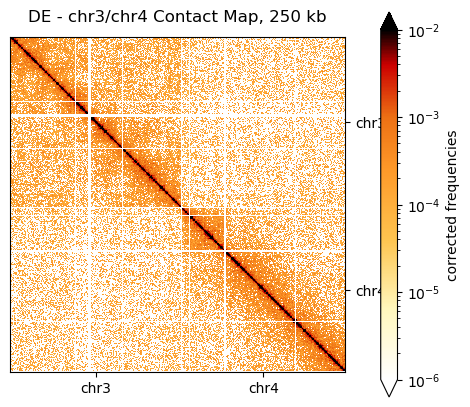

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp1_chr3_chr4_250kb.pdf


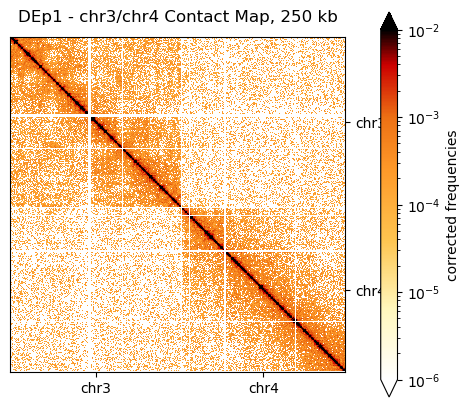

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp2_chr3_chr4_250kb.pdf


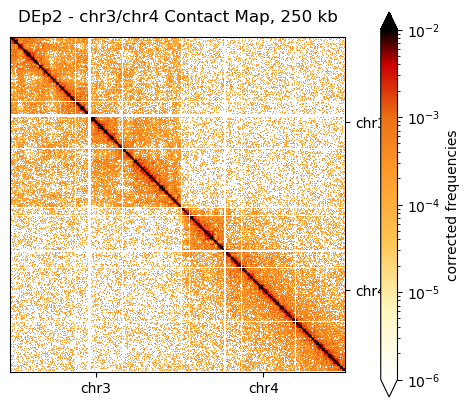

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp3_chr3_chr4_250kb.pdf


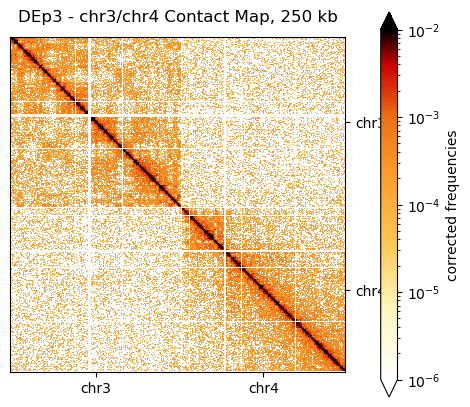

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp4_chr3_chr4_250kb.pdf


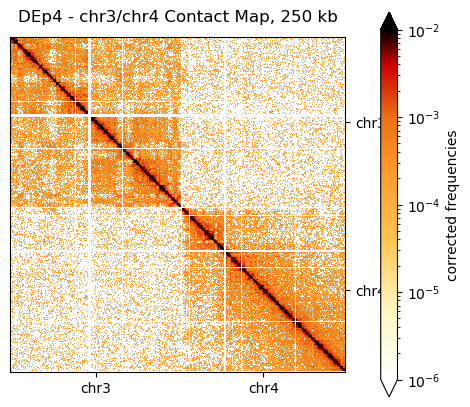

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp5_chr3_chr4_250kb.pdf


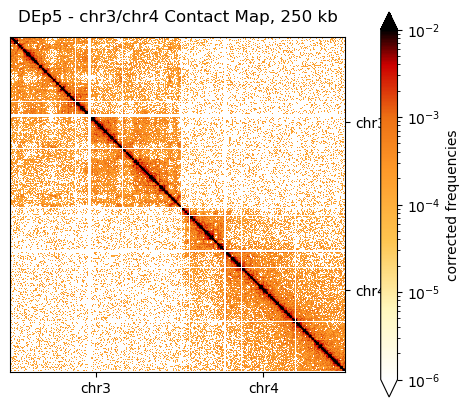

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp6_chr3_chr4_250kb.pdf


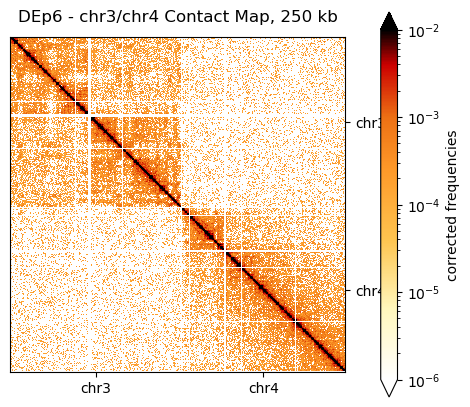

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp7_chr3_chr4_250kb.pdf


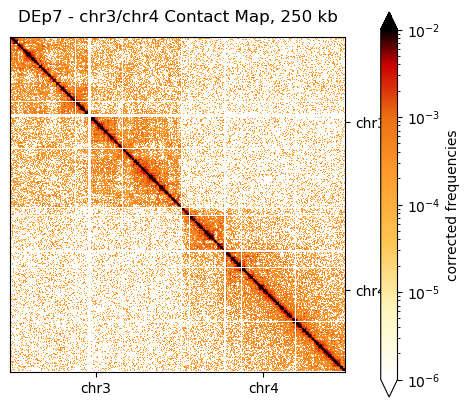

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_HB_chr3_chr4_250kb.pdf


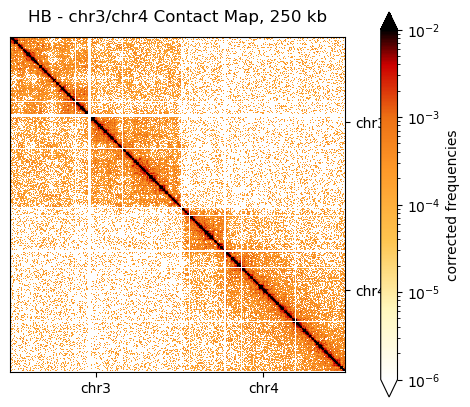

In [33]:
# =========================
# Plot chr3 and chr4 square contact map
# =========================

chrom3 = "chr3"
chrom4 = "chr4"

norm = LogNorm(vmin=1e-6, vmax=0.01)

save_dir = figureDir
os.makedirs(save_dir, exist_ok=True)

for cond in conditions:
    clr = clrs[cond]

    # Fetch 4 blocks
    mat33 = clr.matrix(balance=True).fetch(chrom3, chrom3)
    mat34 = clr.matrix(balance=True).fetch(chrom3, chrom4)
    mat43 = clr.matrix(balance=True).fetch(chrom4, chrom3)
    mat44 = clr.matrix(balance=True).fetch(chrom4, chrom4)

    # Combine into 2x2 block
    top = np.hstack([mat33, mat34])
    bottom = np.hstack([mat43, mat44])
    full_matrix = np.vstack([top, bottom])

    # Chromosome sizes
    len3 = clr.chromsizes[chrom3]
    len4 = clr.chromsizes[chrom4]

    extent = [0, len3 + len4, len3 + len4, 0]

    # Plot
    fig = plt.figure(figsize=(5, 5))

    gs00 = GridSpec(
        nrows=1,
        ncols=2,
        width_ratios=[20, 1],
        wspace=0.2
    )

    ax = plt.subplot(gs00[0, 0])

    im = ax.matshow(
        full_matrix,
        norm=norm,
        cmap="fall",
        extent=extent
    )

    ax.set_xticks([len3 / 2, len3 + len4 / 2])
    ax.set_xticklabels([chrom3, chrom4])

    ax.set_yticks([len3 / 2, len3 + len4 / 2])
    ax.set_yticklabels([chrom3, chrom4])

    ax.xaxis.tick_bottom()
    ax.yaxis.tick_right()

    ax.set_title(
        f"{cond} - {chrom3}/{chrom4} Contact Map, {binsize // 1000} kb",
        y=1.02
    )

    ax.set_aspect("equal")

    # Colorbar
    colorAx = plt.subplot(gs00[0, 1])
    cb = plt.colorbar(im, cax=colorAx, extend="both")
    cb.set_label("corrected frequencies")

    # Save
    save_path = os.path.join(
        save_dir,
        f"Heatmap_{cond}_{chrom3}_{chrom4}_{binsize // 1000}kb.pdf"
    )

    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {save_path}")

    plt.show()

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DE_chr3_130Mb_190Mb_100kb.pdf


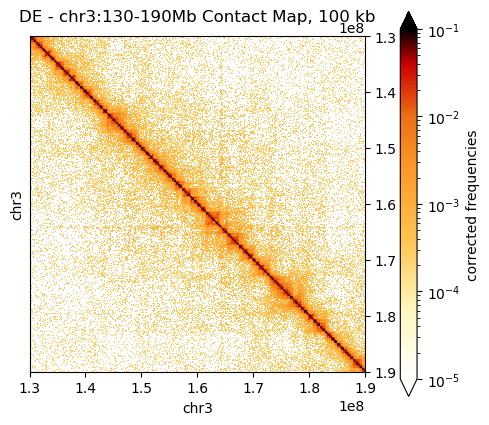

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp1_chr3_130Mb_190Mb_100kb.pdf


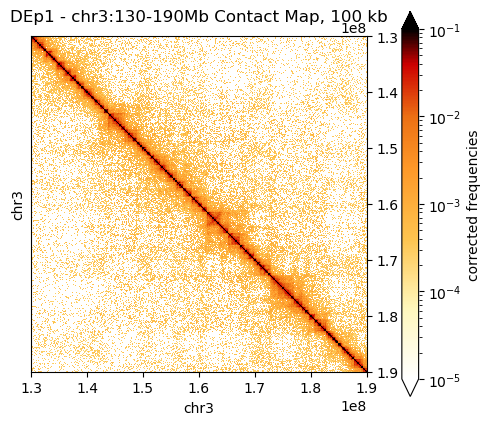

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp2_chr3_130Mb_190Mb_100kb.pdf


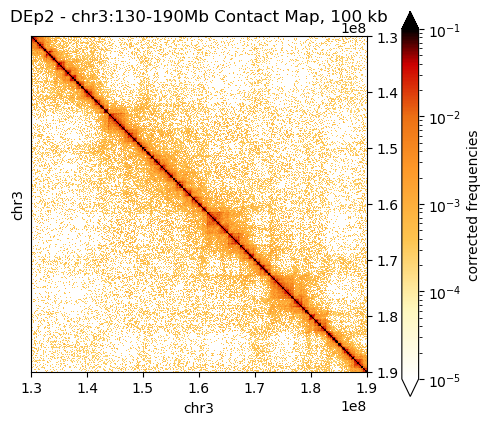

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp3_chr3_130Mb_190Mb_100kb.pdf


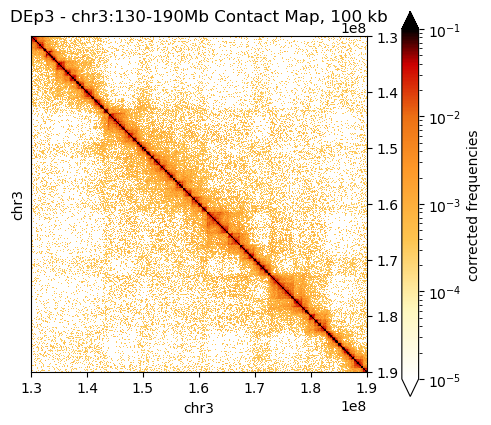

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp4_chr3_130Mb_190Mb_100kb.pdf


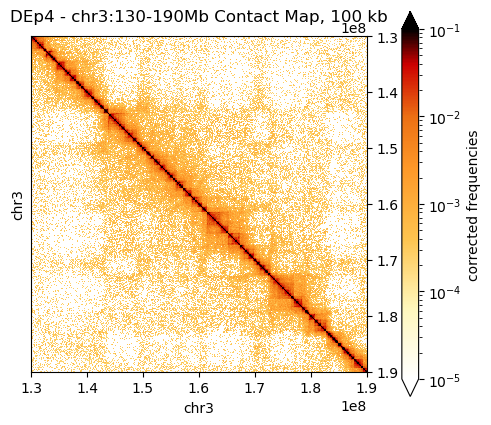

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp5_chr3_130Mb_190Mb_100kb.pdf


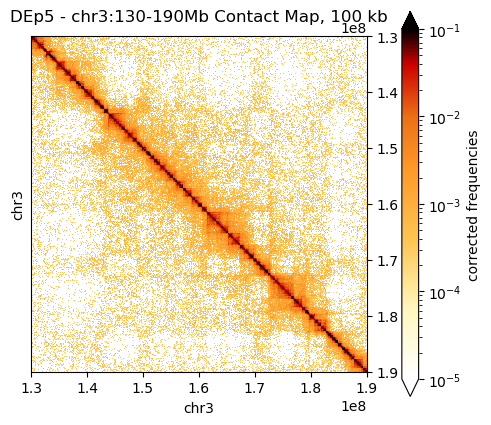

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp6_chr3_130Mb_190Mb_100kb.pdf


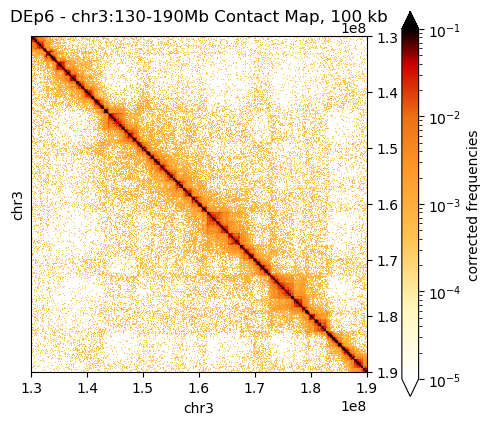

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_DEp7_chr3_130Mb_190Mb_100kb.pdf


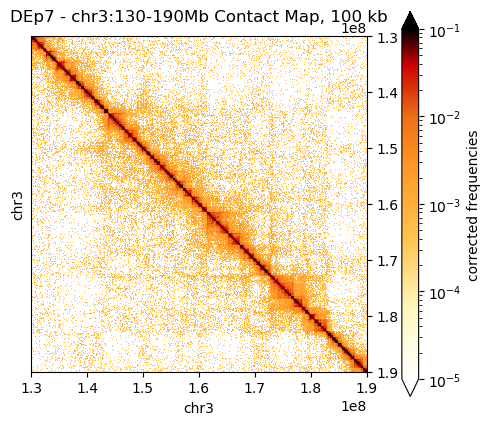

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_HB_chr3_130Mb_190Mb_100kb.pdf


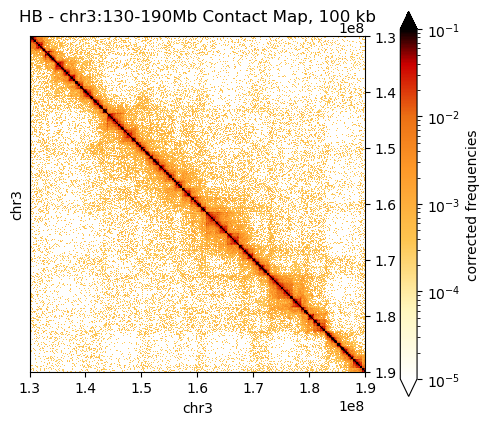

In [46]:
#plot chr3
chrom = "chr3"
start = 130_000_000
end = 190_000_000
region = (chrom, start, end)

region_label = "130Mb_190Mb"

norm = LogNorm(vmin=1e-5, vmax=0.1)

save_dir = figureDir
os.makedirs(save_dir, exist_ok=True)

for cond in conditions:
    clr = clrs[cond]

    # Fetch chr3:130-190Mb matrix
    mat = clr.matrix(balance=True).fetch(region)

    # Plot
    fig = plt.figure(figsize=(5, 5))

    gs00 = GridSpec(
        nrows=1,
        ncols=2,
        width_ratios=[20, 1],
        wspace=0.2
    )

    ax = plt.subplot(gs00[0, 0])
    im = ax.matshow(
        mat,
        norm=norm,
        cmap="fall",
        extent=[start, end, end, start]
    )

    ax.xaxis.tick_bottom()
    ax.yaxis.tick_right()

    ax.set_title(
        f"{cond} - {chrom}:{start//1_000_000}-{end//1_000_000}Mb Contact Map, {binsize // 1000} kb",
        y=1.02
    )

    ax.set_xlabel(chrom)
    ax.set_ylabel(chrom)
    ax.set_aspect("equal")

    # Colorbar
    colorAx = plt.subplot(gs00[0, 1])
    cb = plt.colorbar(im, cax=colorAx, extend="both")
    cb.set_label("corrected frequencies")

    # Save
    save_path = os.path.join(
        save_dir,
        f"Heatmap_{cond}_{chrom}_{region_label}_{binsize // 1000}kb.pdf"
    )

    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {save_path}")

    plt.show()

In [47]:
#H9 load

In [50]:
conditions = [
#     'DE_R1','DE_R2',
    'H9-DE','H9-DEp1','H9-DEp2','H9-DEp3','H9-DEp4','H9-DEp5','H9-DEp6','H9-DEp7','H9-HB',
#     'HB_R1','HB_R2'
]

example = conditions[0]

# note that there is 1 lane of R1 and R2 libraries to reduce size

long_names = {
    'H9-DE': 'H9ESCNup155_DE_20241021',
    'H9-DEp1': 'H9ESCNup155_DEp1_20241021',
    'H9-DEp2': 'H9ESCNup155_DEp2_20241021',
    'H9-DEp3': 'H9ESCNup155_DEp3_20241021',
    'H9-DEp4': 'H9ESCNup155_DEp4_20241021',
    'H9-DEp5': 'H9ESCNup155_DEp5_20241021',
    'H9-DEp6': 'H9ESCNup155_DEp6_20241021',
    'H9-DEp7': 'H9ESCNup155_DEp7_20241021',
    'H9-HB': 'H9ESCNup155_HB_20241021',
}

colors = {
    'H9-DE': '#ffffcc',
    'H9-DEp1': '#ffeda0',
    'H9-DEp2': '#fed976',
    'H9-DEp3': '#feb24c',
    'H9-DEp4': '#fd8d3c',
    'H9-DEp5': '#fc4e2a',
    'H9-DEp6': '#e31a1c',
    'H9-DEp7': '#bd0026',
    'H9-HB': '#800026',
}


coolerDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/coolers'
OutDataDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/scaling'
figureDir = f'/sharehome/xiangruhuo/4DN_scripts/plot'

example = conditions[0]
binsize = 100000 

# Load coolers from conditions/Long names
coolersPath = {}
for cond in conditions:
    coolersPath[cond] = '{}/{}.hg38.mapq_30.1000.mcool::resolutions/{}'.format(coolerDir,long_names[cond],binsize)

clrs = {
cond: cooler.Cooler(coolersPath[cond]) for cond in conditions
}

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DE_chr3_chr4_250kb.pdf


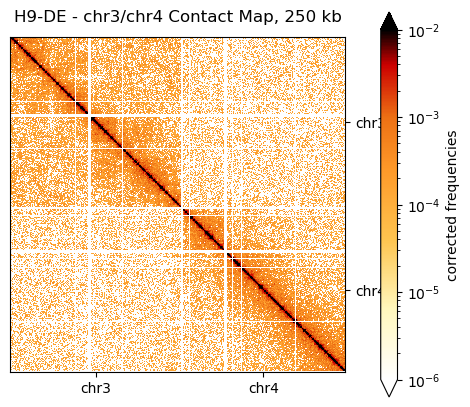

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp1_chr3_chr4_250kb.pdf


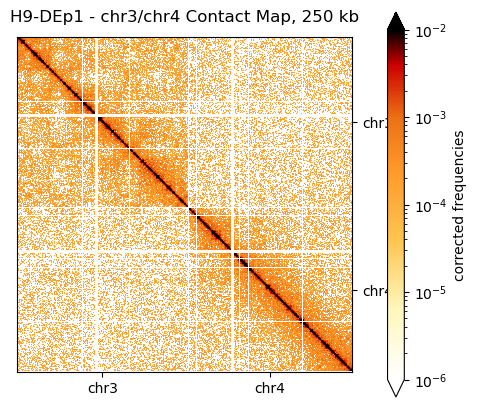

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp2_chr3_chr4_250kb.pdf


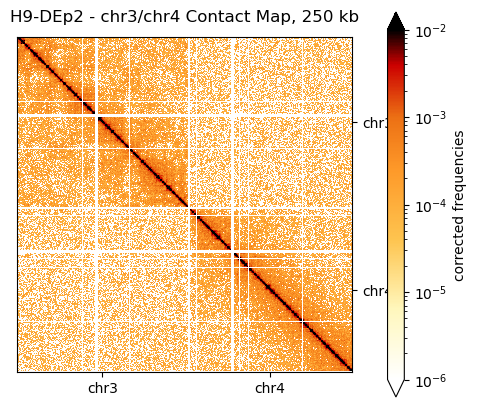

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp3_chr3_chr4_250kb.pdf


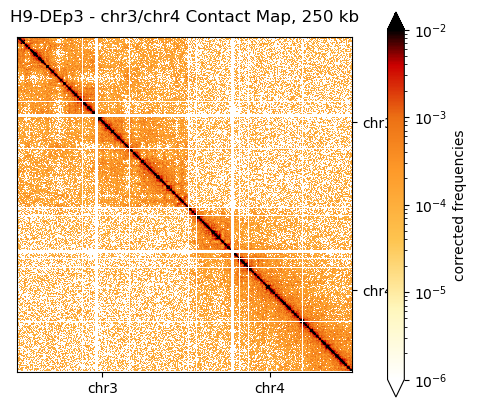

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp4_chr3_chr4_250kb.pdf


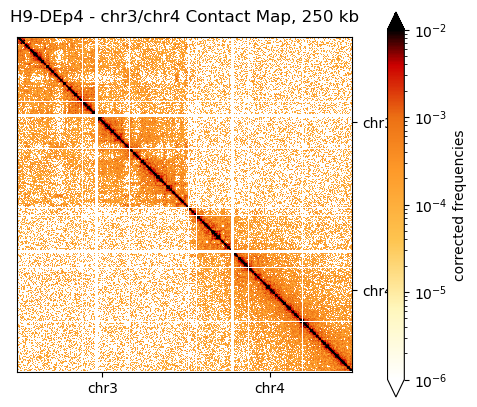

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp5_chr3_chr4_250kb.pdf


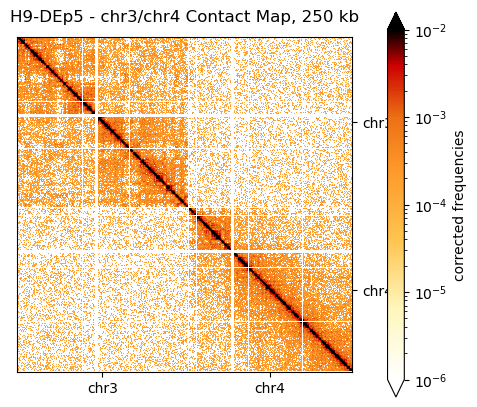

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp6_chr3_chr4_250kb.pdf


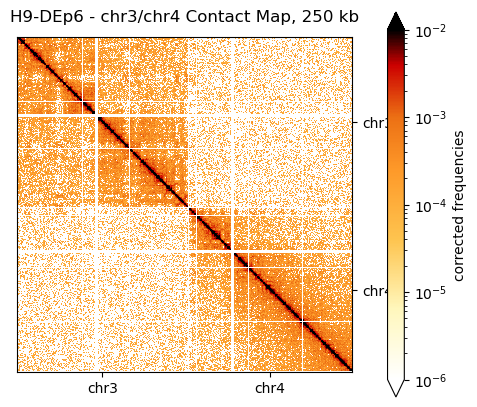

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp7_chr3_chr4_250kb.pdf


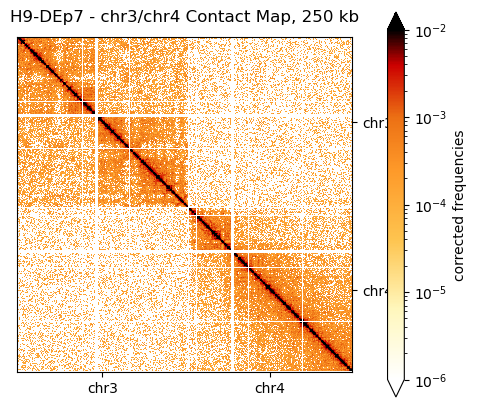

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-HB_chr3_chr4_250kb.pdf


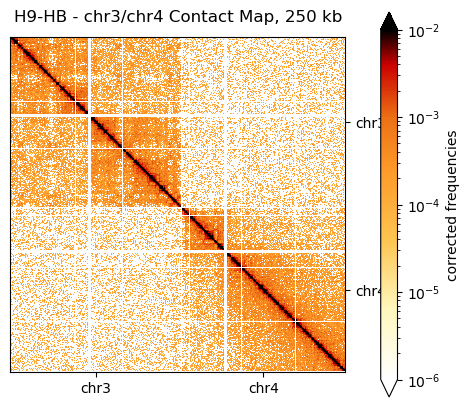

In [49]:
# =========================
# Plot chr3 and chr4 square contact map
# =========================

chrom3 = "chr3"
chrom4 = "chr4"

norm = LogNorm(vmin=1e-6, vmax=0.01)

save_dir = figureDir
os.makedirs(save_dir, exist_ok=True)

for cond in conditions:
    clr = clrs[cond]

    # Fetch 4 blocks
    mat33 = clr.matrix(balance=True).fetch(chrom3, chrom3)
    mat34 = clr.matrix(balance=True).fetch(chrom3, chrom4)
    mat43 = clr.matrix(balance=True).fetch(chrom4, chrom3)
    mat44 = clr.matrix(balance=True).fetch(chrom4, chrom4)

    # Combine into 2x2 block
    top = np.hstack([mat33, mat34])
    bottom = np.hstack([mat43, mat44])
    full_matrix = np.vstack([top, bottom])

    # Chromosome sizes
    len3 = clr.chromsizes[chrom3]
    len4 = clr.chromsizes[chrom4]

    extent = [0, len3 + len4, len3 + len4, 0]

    # Plot
    fig = plt.figure(figsize=(5, 5))

    gs00 = GridSpec(
        nrows=1,
        ncols=2,
        width_ratios=[20, 1],
        wspace=0.2
    )

    ax = plt.subplot(gs00[0, 0])
    im = ax.matshow(
        full_matrix,
        norm=norm,
        cmap="fall",
        extent=extent
    )

    ax.set_xticks([len3 / 2, len3 + len4 / 2])
    ax.set_xticklabels([chrom3, chrom4])

    ax.set_yticks([len3 / 2, len3 + len4 / 2])
    ax.set_yticklabels([chrom3, chrom4])

    ax.xaxis.tick_bottom()
    ax.yaxis.tick_right()

    ax.set_title(
        f"{cond} - {chrom3}/{chrom4} Contact Map, {binsize // 1000} kb",
        y=1.02
    )

    ax.set_aspect("equal")

    # Colorbar
    colorAx = plt.subplot(gs00[0, 1])
    cb = plt.colorbar(im, cax=colorAx, extend="both")
    cb.set_label("corrected frequencies")

    # Save
    save_path = os.path.join(
        save_dir,
        f"Heatmap_H9_{cond}_{chrom3}_{chrom4}_{binsize // 1000}kb.pdf"
    )

    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {save_path}")

    plt.show()

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DE_chr3_130Mb_190Mb_100kb.pdf


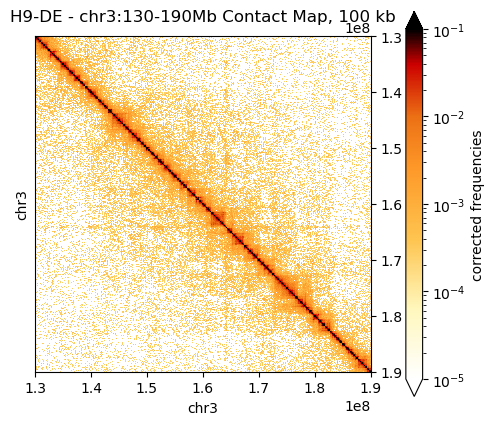

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp1_chr3_130Mb_190Mb_100kb.pdf


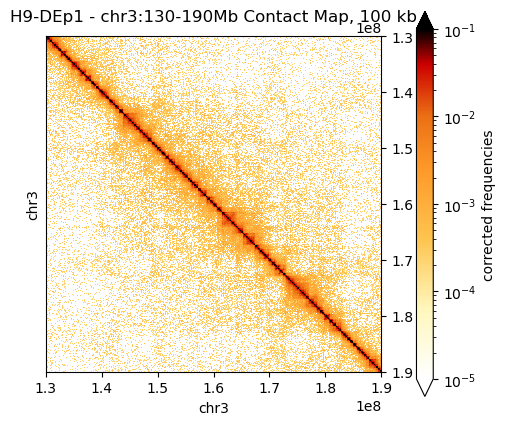

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp2_chr3_130Mb_190Mb_100kb.pdf


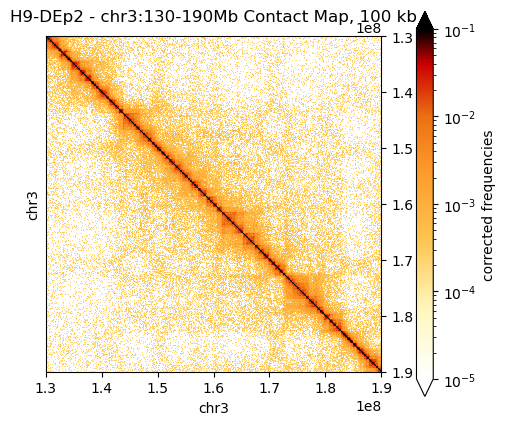

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp3_chr3_130Mb_190Mb_100kb.pdf


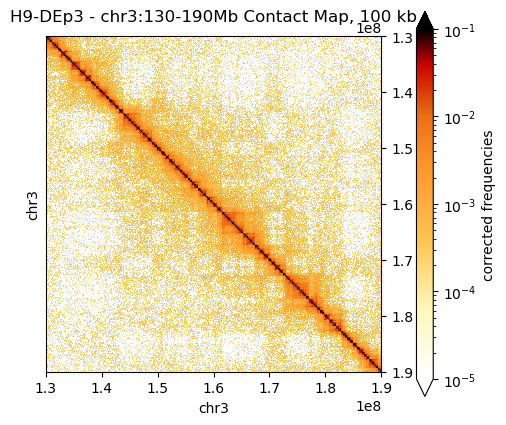

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp4_chr3_130Mb_190Mb_100kb.pdf


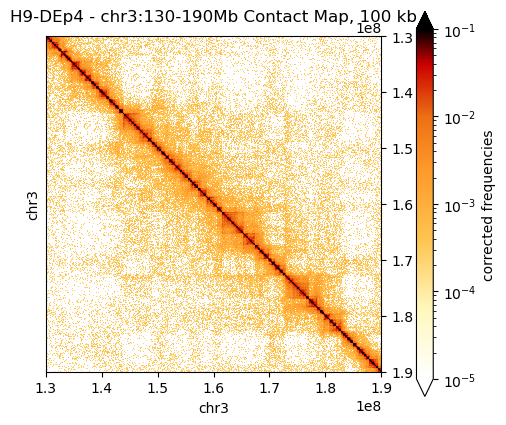

Saved: /sharehome/xiangruhuo/4DN_scripts/plot/Heatmap_H9_H9-DEp5_chr3_130Mb_190Mb_100kb.pdf


In [ ]:
#plot chr3
chrom = "chr3"
start = 130_000_000
end = 190_000_000
region = (chrom, start, end)

region_label = "130Mb_190Mb"

norm = LogNorm(vmin=1e-5, vmax=0.1)

save_dir = figureDir
os.makedirs(save_dir, exist_ok=True)

for cond in conditions:
    clr = clrs[cond]

    # Fetch chr3:130-190Mb matrix
    mat = clr.matrix(balance=True).fetch(region)

    # Plot
    fig = plt.figure(figsize=(5, 5))

    gs00 = GridSpec(
        nrows=1,
        ncols=2,
        width_ratios=[20, 1],
        wspace=0.2
    )

    ax = plt.subplot(gs00[0, 0])
    im = ax.matshow(
        mat,
        norm=norm,
        cmap="fall",
        extent=[start, end, end, start]
    )

    ax.xaxis.tick_bottom()
    ax.yaxis.tick_right()

    ax.set_title(
        f"{cond} - {chrom}:{start//1_000_000}-{end//1_000_000}Mb Contact Map, {binsize // 1000} kb",
        y=1.02
    )

    ax.set_xlabel(chrom)
    ax.set_ylabel(chrom)
    ax.set_aspect("equal")

    # Colorbar
    colorAx = plt.subplot(gs00[0, 1])
    cb = plt.colorbar(im, cax=colorAx, extend="both")
    cb.set_label("corrected frequencies")

    # Save
    save_path = os.path.join(
        save_dir,
        f"Heatmap_H9_{cond}_{chrom}_{region_label}_{binsize // 1000}kb.pdf"
    )

    plt.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {save_path}")

    plt.show()